# Teen Mental Health Segmentation using K-Means Clustering

**Objective:** Build a simple Data Analytics and Machine Learning project that segments teenagers into Healthy Lifestyle, Moderate Risk, and High Risk groups using K-Means Clustering.

**Important note:** This project is for learning and data analysis only. It should not be used as a medical diagnosis tool.

## 1. Import Required Libraries

The project uses only beginner-friendly Python libraries: Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn.

In [1]:
# Basic libraries
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Display helper for tables
from IPython.display import display

# Keep notebook output clean
warnings.filterwarnings("ignore")
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

## 2. Data Loading and Understanding

This section loads the dataset and displays the shape, column names, data types, first few rows, and statistical summary.

In [2]:
# The notebook first checks the project folder, then the original Downloads path.
possible_paths = [
    Path("Teen_Mental_Health_Dataset.csv"),
    Path(r"C:\Users\Meena\Downloads\Teen_Mental_Health_Dataset.csv")
]

dataset_path = None
for path in possible_paths:
    if path.exists():
        dataset_path = path
        break

if dataset_path is None:
    raise FileNotFoundError("Teen_Mental_Health_Dataset.csv was not found. Place it in the same folder as this notebook.")

df = pd.read_csv(dataset_path)

print("Dataset path:", dataset_path)
print("Dataset shape:", df.shape)

Dataset path: Teen_Mental_Health_Dataset.csv
Dataset shape: (1200, 13)


In [3]:
print("Column names:")
print(df.columns.tolist())

Column names:
['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']


In [4]:
print("Data types:")
print(df.dtypes)

Data types:
age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object


In [5]:
print("First few rows:")
display(df.head())

First few rows:


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [6]:
print("Statistical summary:")
display(df.describe())

Statistical summary:


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


## 3. Data Cleaning

Cleaning steps:

- Check and handle missing values
- Identify and remove duplicate rows
- Check text consistency
- Detect outliers using the IQR method
- Visualize outliers using boxplots
- Cap extreme outliers only if needed

### 3.1 Missing Values

In [7]:
# Check missing values in each column
missing_values = df.isnull().sum()
print("Missing values:")
print(missing_values)

Missing values:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [8]:
# Fill missing values if any are found.
# Numeric columns are filled with median.
# Categorical columns are filled with mode.
df_clean = df.copy()

for column in df_clean.columns:
    if df_clean[column].isnull().sum() > 0:
        if df_clean[column].dtype == "object":
            df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])
        else:
            df_clean[column] = df_clean[column].fillna(df_clean[column].median())

print("Total missing values after handling:", df_clean.isnull().sum().sum())

Total missing values after handling: 0


### 3.2 Duplicate Records

In [9]:
duplicate_count = df_clean.duplicated().sum()
print("Duplicate rows found:", duplicate_count)

# Remove duplicate rows if found
df_clean = df_clean.drop_duplicates()
print("Shape after removing duplicates:", df_clean.shape)

Duplicate rows found: 0
Shape after removing duplicates: (1200, 13)


### 3.3 Data Consistency

In [10]:
# Clean text columns by removing extra spaces and converting to lowercase.
# Regex is not required because this dataset only needs simple text consistency.
text_columns = df_clean.select_dtypes(include="object").columns

for column in text_columns:
    df_clean[column] = df_clean[column].str.strip().str.lower()

print("Text columns checked:", text_columns.tolist())

for column in text_columns:
    print("\nUnique values in", column)
    print(df_clean[column].value_counts())

Text columns checked: ['gender', 'platform_usage', 'social_interaction_level']

Unique values in gender
gender
male      615
female    585
Name: count, dtype: int64

Unique values in platform_usage
platform_usage
instagram    411
tiktok       398
both         391
Name: count, dtype: int64

Unique values in social_interaction_level
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64


### 3.4 Outlier Detection using IQR

In [11]:
# Important numeric columns for outlier detection
outlier_columns = [
    "age",
    "daily_social_media_hours",
    "sleep_hours",
    "physical_activity",
    "stress_level",
    "anxiety_level",
    "addiction_level"
]

outlier_summary = []
outlier_bounds = {}

for column in outlier_columns:
    q1 = df_clean[column].quantile(0.25)
    q3 = df_clean[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df_clean[column] < lower_bound) | (df_clean[column] > upper_bound)).sum()

    outlier_bounds[column] = (lower_bound, upper_bound)
    outlier_summary.append([column, lower_bound, upper_bound, outlier_count])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Column", "Lower Bound", "Upper Bound", "Outlier Count"]
)

display(outlier_df)

,Column,Lower Bound,Upper Bound,Outlier Count
0,age,8.00,24.00,0
1,daily_social_media_hours,-2.45,11.55,0
2,sleep_hours,1.60,11.20,0
3,physical_activity,-1.00,3.00,0
4,stress_level,-4.50,15.50,0
5,anxiety_level,-4.50,15.50,0
6,addiction_level,-4.50,15.50,0


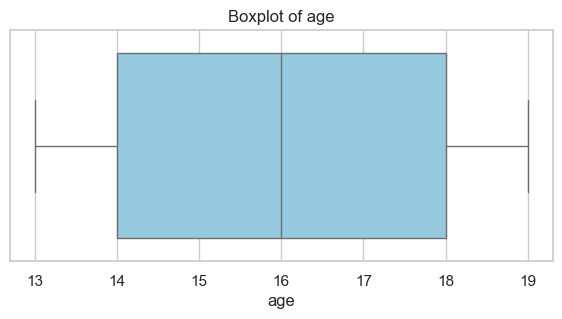

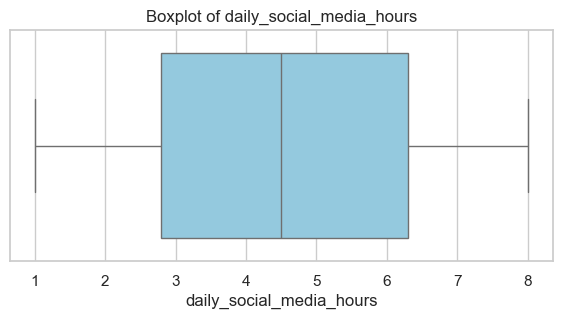

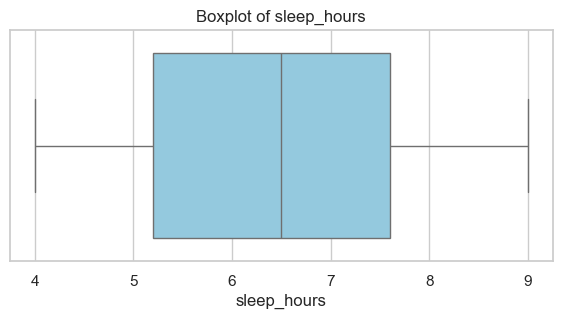

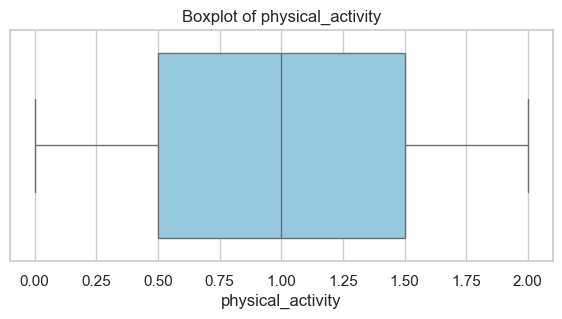

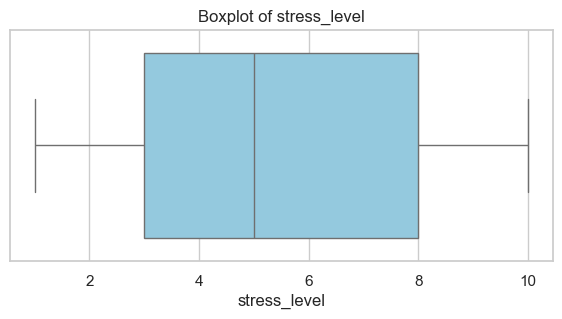

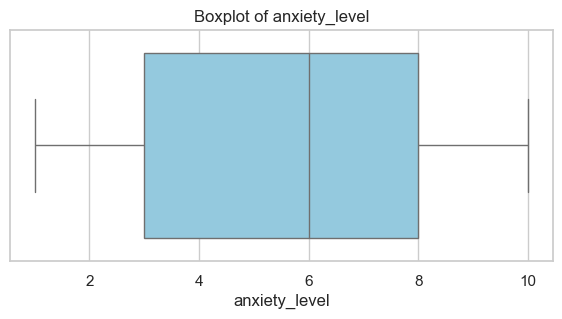

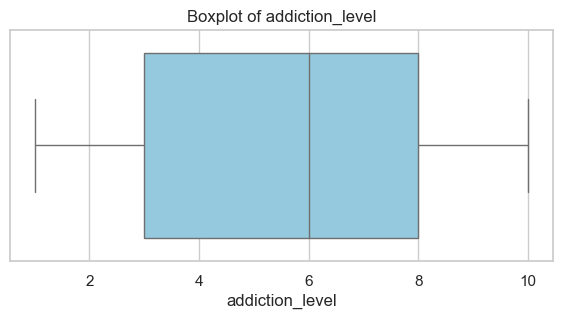

In [12]:
# Boxplots to visualize possible outliers
for column in outlier_columns:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df_clean[column], color="skyblue")
    plt.title("Boxplot of " + column)
    plt.xlabel(column)
    plt.show()

In [13]:
# Cap extreme outliers only if the IQR method finds them.
# In this dataset, most columns are already within expected ranges.
for column in outlier_columns:
    lower_bound, upper_bound = outlier_bounds[column]
    outlier_count = ((df_clean[column] < lower_bound) | (df_clean[column] > upper_bound)).sum()

    if outlier_count > 0:
        df_clean[column] = df_clean[column].clip(lower=lower_bound, upper=upper_bound)

print("Final dataset shape after cleaning:", df_clean.shape)

Final dataset shape after cleaning: (1200, 13)


### Cleaning Observations

- The dataset was checked for missing values, duplicate rows, inconsistent text entries, and outliers.
- Text columns were standardized to lowercase for consistency.
- IQR-based outlier detection was used on important numeric columns.
- Extreme values are capped only if the IQR method identifies them.

## 4. Exploratory Data Analysis (EDA)

EDA is performed only on important variables related to lifestyle and mental health indicators.

### 4.1 Univariate Analysis

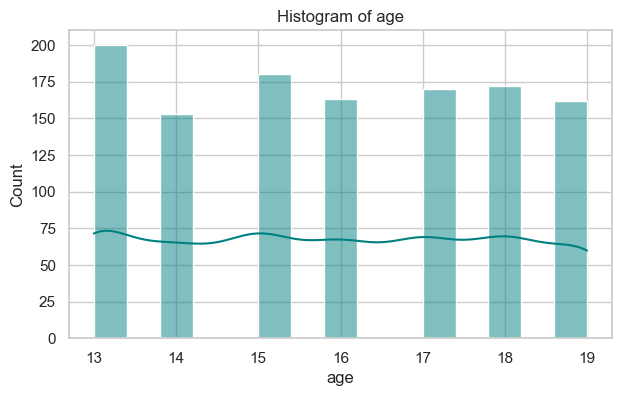

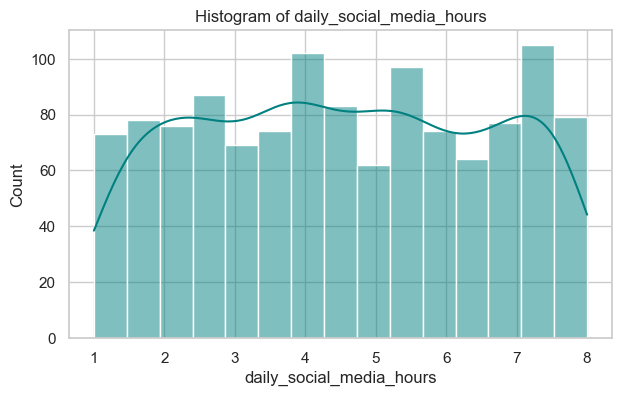

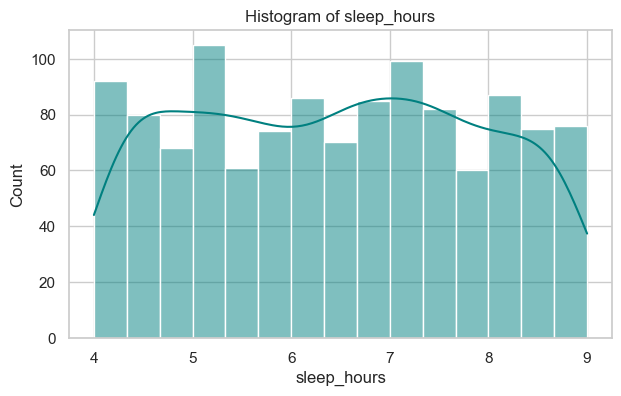

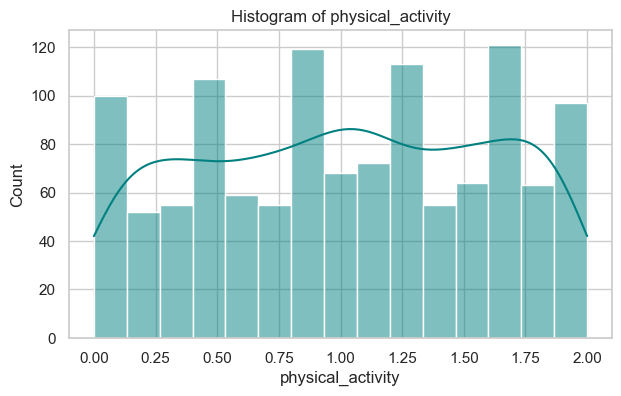

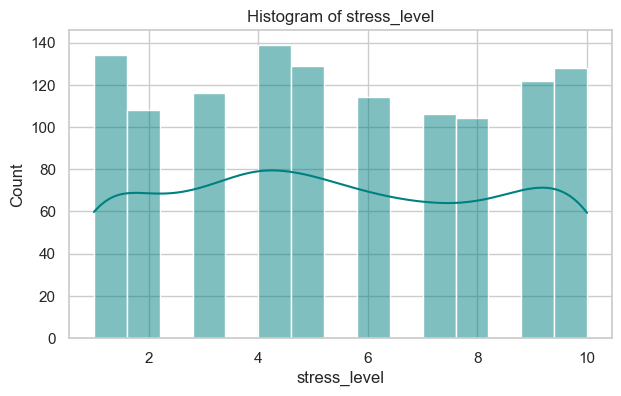

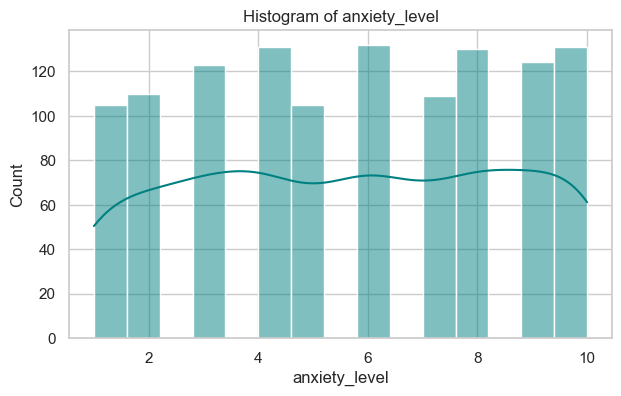

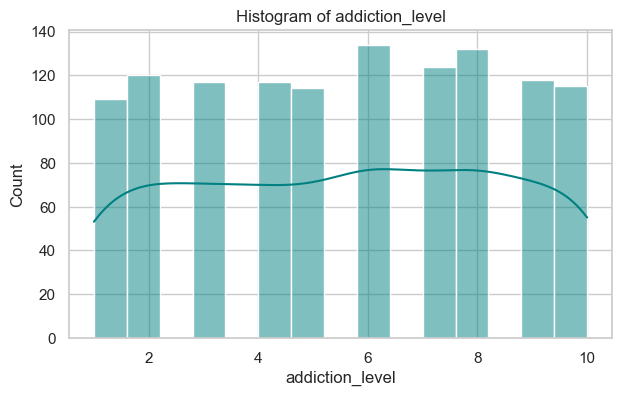

In [14]:
univariate_columns = [
    "age",
    "daily_social_media_hours",
    "sleep_hours",
    "physical_activity",
    "stress_level",
    "anxiety_level",
    "addiction_level"
]

# Histograms
for column in univariate_columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(df_clean[column], kde=True, bins=15, color="teal")
    plt.title("Histogram of " + column)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()

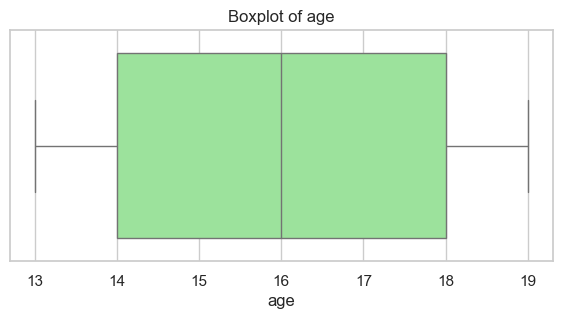

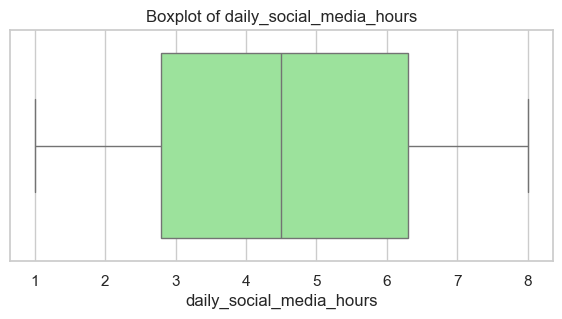

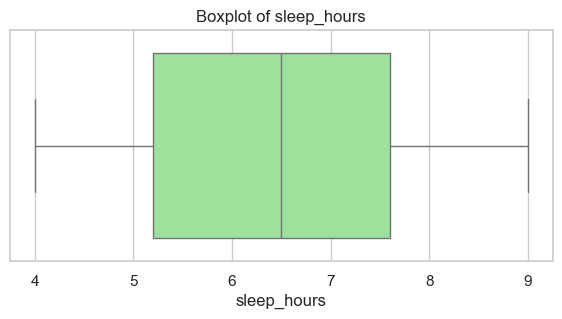

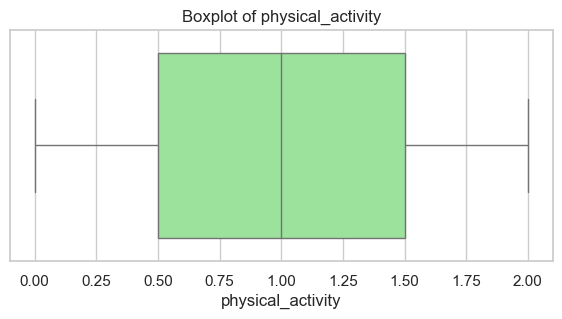

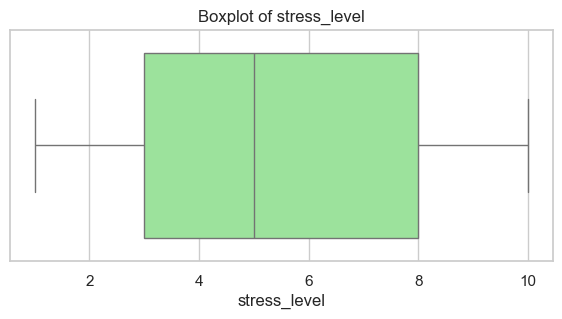

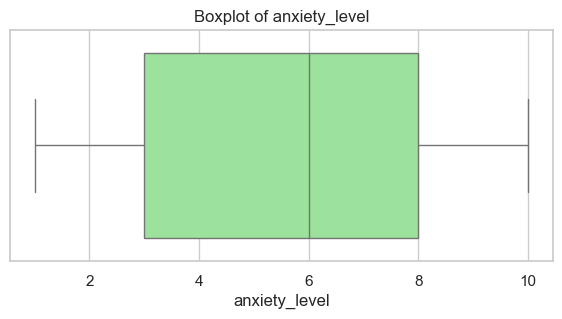

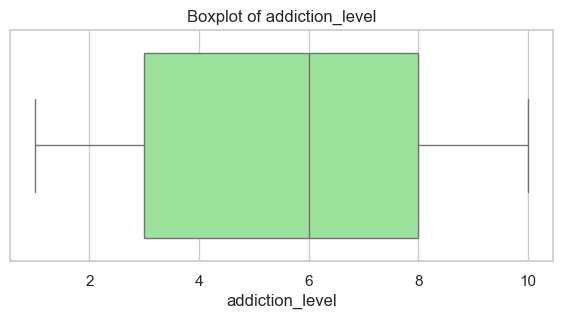

In [15]:
# Boxplots
for column in univariate_columns:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df_clean[column], color="lightgreen")
    plt.title("Boxplot of " + column)
    plt.xlabel(column)
    plt.show()

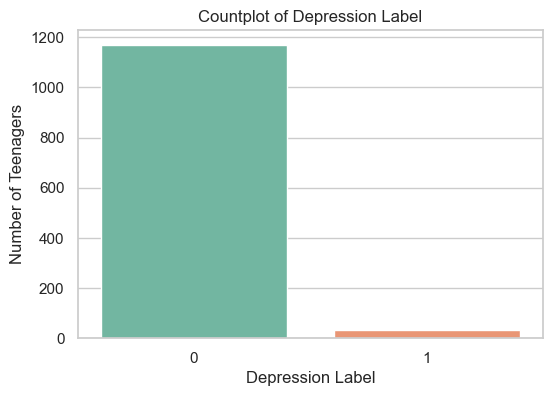

Depression label counts:
depression_label
0    1169
1      31
Name: count, dtype: int64


In [16]:
# Countplot for Depression Label
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="depression_label", palette="Set2")
plt.title("Countplot of Depression Label")
plt.xlabel("Depression Label")
plt.ylabel("Number of Teenagers")
plt.show()

print("Depression label counts:")
print(df_clean["depression_label"].value_counts().sort_index())

### Univariate Observations

- **Age:** The teenagers are between 13 and 19 years old.
- **Daily Social Media Hours:** Usage ranges from low to high, with many students around the middle of the range.
- **Sleep Hours:** Sleep varies from short sleep to healthier sleep duration.
- **Physical Activity:** Activity levels are generally low to moderate.
- **Stress Level:** Stress scores are spread across the full range, so students show different stress patterns.
- **Anxiety Level:** Anxiety scores also vary widely across students.
- **Addiction Level:** Addiction scores range from low to high.
- **Depression Label:** The depression label is highly imbalanced, with many more 0 values than 1 values.

### 4.2 Bivariate Analysis

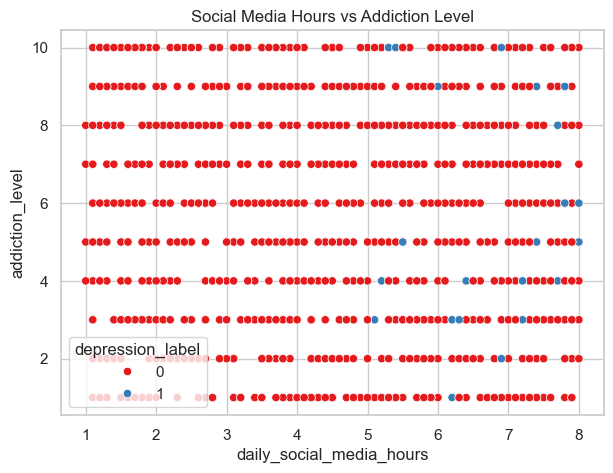

In [17]:
# Social Media Hours vs Addiction Level
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df_clean,
    x="daily_social_media_hours",
    y="addiction_level",
    hue="depression_label",
    palette="Set1"
)
plt.title("Social Media Hours vs Addiction Level")
plt.show()

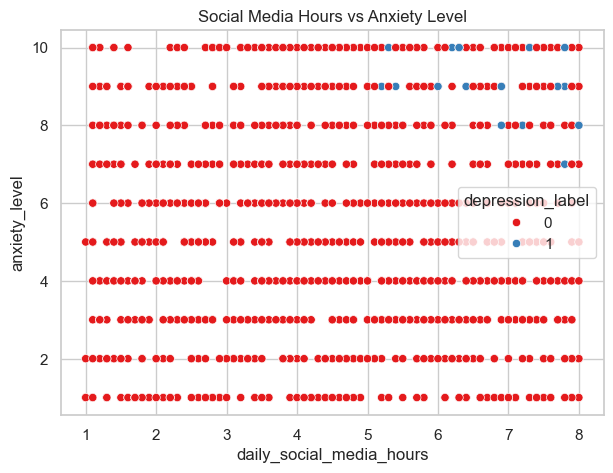

In [18]:
# Social Media Hours vs Anxiety Level
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df_clean,
    x="daily_social_media_hours",
    y="anxiety_level",
    hue="depression_label",
    palette="Set1"
)
plt.title("Social Media Hours vs Anxiety Level")
plt.show()

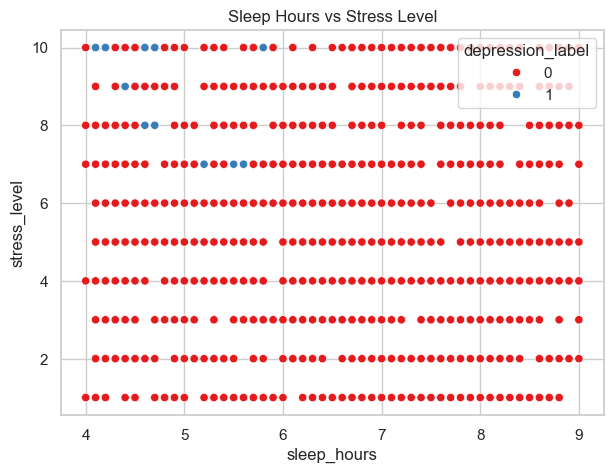

In [19]:
# Sleep Hours vs Stress Level
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df_clean,
    x="sleep_hours",
    y="stress_level",
    hue="depression_label",
    palette="Set1"
)
plt.title("Sleep Hours vs Stress Level")
plt.show()

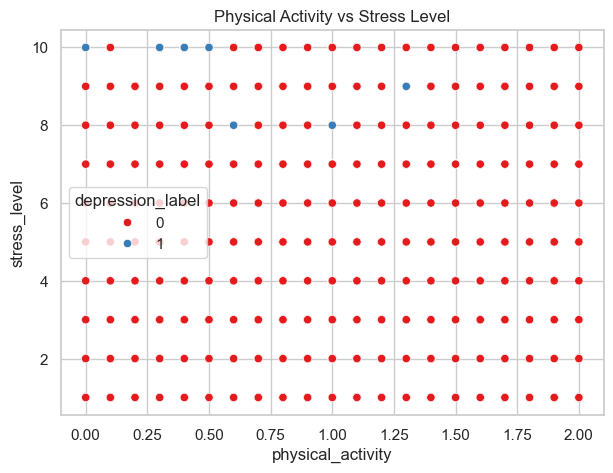

In [20]:
# Physical Activity vs Stress Level
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df_clean,
    x="physical_activity",
    y="stress_level",
    hue="depression_label",
    palette="Set1"
)
plt.title("Physical Activity vs Stress Level")
plt.show()

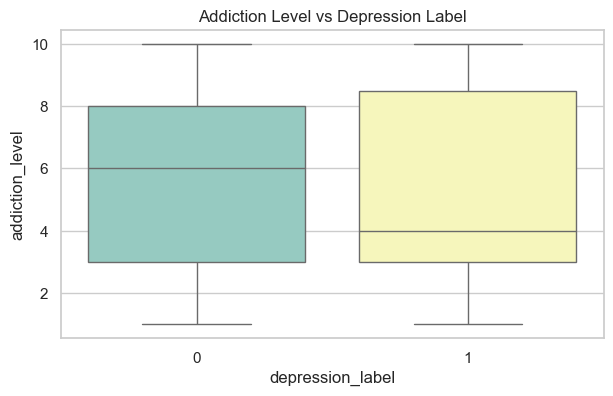

In [21]:
# Addiction Level vs Depression Label
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df_clean,
    x="depression_label",
    y="addiction_level",
    palette="Set3"
)
plt.title("Addiction Level vs Depression Label")
plt.show()

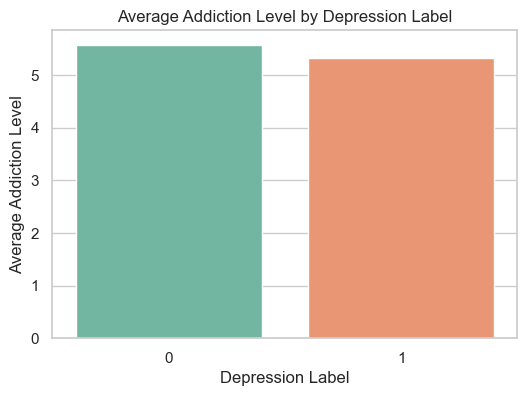

,depression_label,addiction_level
0,0,5.571429
1,1,5.322581


In [22]:
# Bar chart: average addiction level by depression label
addiction_by_depression = df_clean.groupby("depression_label")["addiction_level"].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(
    data=addiction_by_depression,
    x="depression_label",
    y="addiction_level",
    palette="Set2"
)
plt.title("Average Addiction Level by Depression Label")
plt.xlabel("Depression Label")
plt.ylabel("Average Addiction Level")
plt.show()

display(addiction_by_depression)

In [23]:
# Compare important averages by depression label
depression_group_summary = df_clean.groupby("depression_label")[
    [
        "daily_social_media_hours",
        "sleep_hours",
        "physical_activity",
        "stress_level",
        "anxiety_level",
        "addiction_level"
    ]
].mean().round(2)

display(depression_group_summary)

,daily_social_media_hours,sleep_hours,physical_activity,stress_level,anxiety_level,addiction_level
depression_label,,,,,,
0,4.48,6.49,1.02,5.37,5.56,5.57
1,6.72,4.76,0.95,8.48,8.61,5.32


### Bivariate Insights

- **Social Media Hours vs Addiction Level:** Students with higher social media use should be watched carefully because addiction scores can rise with heavier usage.
- **Social Media Hours vs Anxiety Level:** Higher usage can appear with higher anxiety scores, although the pattern should be checked with correlation too.
- **Sleep Hours vs Stress Level:** Students with lower sleep and higher stress are important to monitor.
- **Physical Activity vs Stress Level:** Lower activity may be linked with less healthy stress patterns.
- **Addiction Level vs Depression Label:** The depression group is small, so conclusions should be careful. Group averages and boxplots help compare the two labels.

### 4.3 Multivariate Analysis

In [24]:
correlation_columns = [
    "daily_social_media_hours",
    "sleep_hours",
    "physical_activity",
    "stress_level",
    "anxiety_level",
    "addiction_level"
]

correlation_matrix = df_clean[correlation_columns].corr()
print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,daily_social_media_hours,sleep_hours,physical_activity,stress_level,anxiety_level,addiction_level
daily_social_media_hours,1.000000,-0.009472,0.025546,0.030698,0.027835,-0.024964
sleep_hours,-0.009472,1.000000,0.012701,-0.010979,-0.011879,-0.054838
physical_activity,0.025546,0.012701,1.000000,0.012159,-0.022233,0.026200
stress_level,0.030698,-0.010979,0.012159,1.000000,0.015811,-0.000129
anxiety_level,0.027835,-0.011879,-0.022233,0.015811,1.000000,0.031154
addiction_level,-0.024964,-0.054838,0.026200,-0.000129,0.031154,1.000000


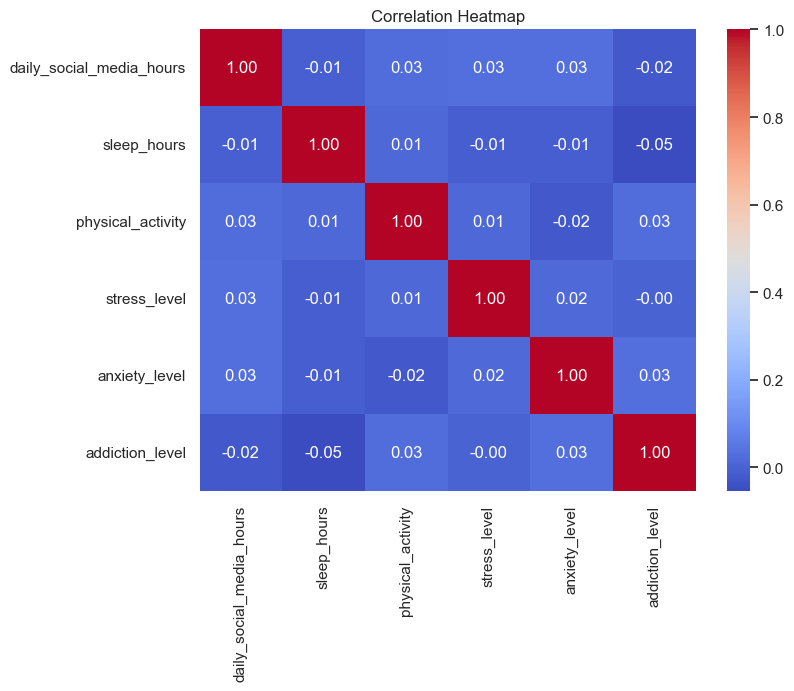

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

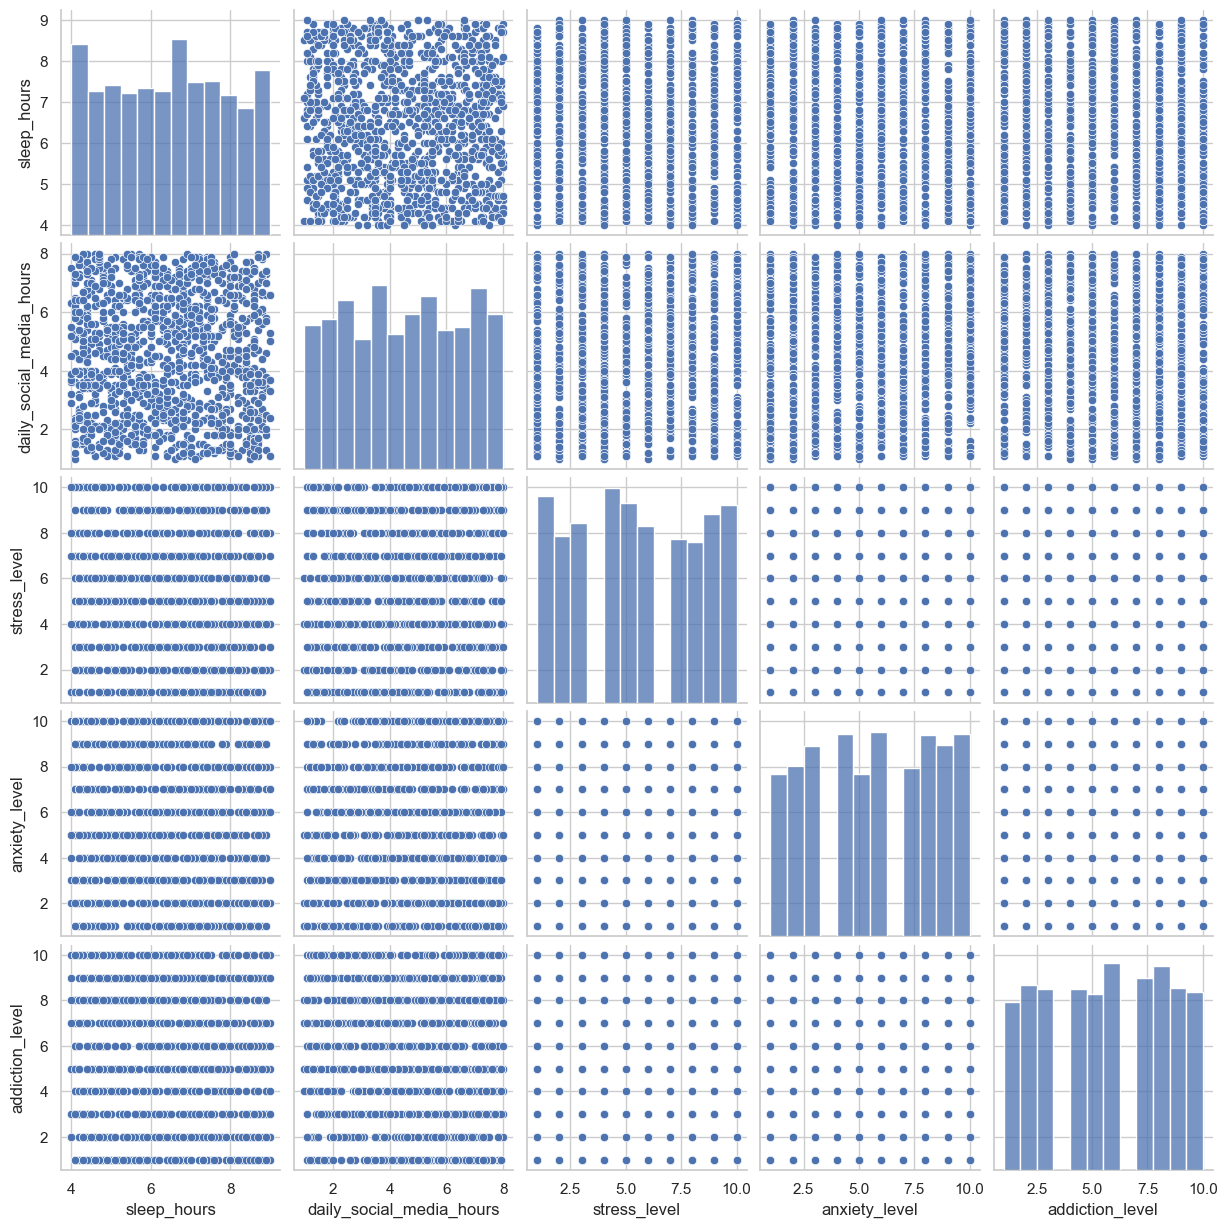

In [26]:
pairplot_columns = [
    "sleep_hours",
    "daily_social_media_hours",
    "stress_level",
    "anxiety_level",
    "addiction_level"
]

sns.pairplot(df_clean[pairplot_columns], diag_kind="hist")
plt.show()

### Multivariate Key Findings

- The correlation matrix shows how the main mental health and lifestyle factors move together.
- If correlations are weak, K-Means can still group students by overall patterns across multiple variables.
- The pairplot helps visually compare sleep, social media usage, stress, anxiety, and addiction together.

## 5. Data Preprocessing

The clustering model needs selected features and normalized values.

### 5.1 Feature Selection

In [27]:
selected_features = [
    "daily_social_media_hours",
    "sleep_hours",
    "physical_activity",
    "stress_level",
    "anxiety_level",
    "addiction_level"
]

clustering_data = df_clean[selected_features].copy()
print("Selected features for clustering:")
print(selected_features)
display(clustering_data.head())

Selected features for clustering:
['daily_social_media_hours', 'sleep_hours', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']


,daily_social_media_hours,sleep_hours,physical_activity,stress_level,anxiety_level,addiction_level
0,7.9,7.4,1.5,2,2,1
1,1.9,8.0,0.8,8,1,10
2,1.3,7.6,0.0,2,4,2
3,7.4,6.9,0.8,1,7,9
4,4.7,4.9,1.4,3,5,2


### 5.2 Encoding

In [28]:
# The selected clustering features are already numeric.
# If categorical columns were selected, this code would encode them.
categorical_columns = clustering_data.select_dtypes(include="object").columns

if len(categorical_columns) > 0:
    clustering_data = pd.get_dummies(clustering_data, columns=categorical_columns, drop_first=True)
    print("Categorical columns encoded:", categorical_columns.tolist())
else:
    print("No categorical columns selected, so encoding is not needed.")

No categorical columns selected, so encoding is not needed.


### 5.3 Normalization using StandardScaler

In [29]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_data)

processed_df = pd.DataFrame(scaled_data, columns=clustering_data.columns)

print("Processed dataset after StandardScaler:")
display(processed_df.head())

Processed dataset after StandardScaler:


,daily_social_media_hours,sleep_hours,physical_activity,stress_level,anxiety_level,addiction_level
0,1.657833,0.659177,0.834276,-1.187367,-1.272335,-1.613389
1,-1.299649,1.075244,-0.368593,0.880116,-1.622199,1.567444
2,-1.595397,0.797866,-1.743301,-1.187367,-0.572609,-1.259963
3,1.411376,0.312455,-0.368593,-1.531947,0.476980,1.214018
4,0.080509,-1.074435,0.662437,-0.842786,-0.222746,-1.259963


## 6. K-Means Clustering

This section uses the Elbow Method and then builds the final K-Means model with K = 3.

### 6.1 Elbow Method

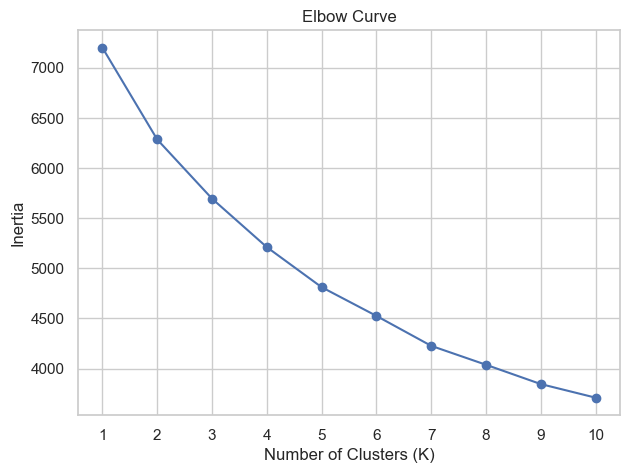

In [30]:
inertia_values = []
k_values = range(1, 11)

for k in k_values:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_model.fit(processed_df)
    inertia_values.append(kmeans_model.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Curve")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.show()

### 6.2 Model Building with K = 3

In [31]:
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
raw_cluster_labels = final_kmeans.fit_predict(processed_df)

df_clustered = df_clean.copy()
df_clustered["raw_cluster"] = raw_cluster_labels

print("Raw cluster labels assigned by K-Means:")
print(df_clustered["raw_cluster"].value_counts().sort_index())

Raw cluster labels assigned by K-Means:
raw_cluster
0    400
1    438
2    362
Name: count, dtype: int64


In [32]:
# K-Means cluster numbers are arbitrary.
# To make the project easy to understand, clusters are reordered by risk score.
raw_cluster_means = df_clustered.groupby("raw_cluster")[selected_features].mean()

risk_score = (
    raw_cluster_means["daily_social_media_hours"]
    + raw_cluster_means["stress_level"]
    + raw_cluster_means["anxiety_level"]
    + raw_cluster_means["addiction_level"]
    - raw_cluster_means["sleep_hours"]
    - raw_cluster_means["physical_activity"]
)

ordered_raw_clusters = risk_score.sort_values().index.tolist()
cluster_mapping = {old_cluster: new_cluster for new_cluster, old_cluster in enumerate(ordered_raw_clusters)}

df_clustered["cluster"] = df_clustered["raw_cluster"].map(cluster_mapping)

cluster_names = {
    0: "Healthy Lifestyle",
    1: "Moderate Risk",
    2: "High Risk"
}

df_clustered["cluster_name"] = df_clustered["cluster"].map(cluster_names)
df_clustered = df_clustered.drop(columns=["raw_cluster"])

print("Final cluster labels:")
print(df_clustered["cluster"].value_counts().sort_index())
display(df_clustered.head())

Final cluster labels:
cluster
0    362
1    400
2    438
Name: count, dtype: int64


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,cluster,cluster_name
0,14,male,7.9,instagram,7.4,2.9,3.01,1.5,low,2,2,1,0,2,High Risk
1,19,female,1.9,tiktok,8.0,2.9,3.22,0.8,high,8,1,10,0,0,Healthy Lifestyle
2,17,female,1.3,instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,1,Moderate Risk
3,15,male,7.4,tiktok,6.9,1.6,3.48,0.8,medium,1,7,9,0,2,High Risk
4,15,female,4.7,both,4.9,3.0,2.37,1.4,medium,3,5,2,0,0,Healthy Lifestyle


## 7. Cluster Analysis and Interpretation

Cluster-wise averages help us understand the lifestyle and mental health pattern of each group.

In [33]:
cluster_summary = df_clustered.groupby(["cluster", "cluster_name"])[
    selected_features + ["depression_label"]
].mean().round(2)

print("Cluster-wise averages:")
display(cluster_summary)

Cluster-wise averages:


,,daily_social_media_hours,sleep_hours,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
cluster,cluster_name,,,,,,,
0,Healthy Lifestyle,2.85,6.39,1.46,5.19,5.33,5.94,0.00
1,Moderate Risk,3.85,6.39,0.40,4.91,5.68,5.12,0.00
2,High Risk,6.56,6.55,1.20,6.15,5.85,5.66,0.07


In [34]:
# Simple interpretation table
cluster_sizes = df_clustered.groupby(["cluster", "cluster_name"]).size().reset_index(name="student_count")
display(cluster_sizes)

,cluster,cluster_name,student_count
0,0,Healthy Lifestyle,362
1,1,Moderate Risk,400
2,2,High Risk,438


### Cluster Interpretation

**Cluster 0 - Healthy Lifestyle**

- This group has the lowest overall risk score.
- Students in this group generally show healthier lifestyle patterns compared with other clusters.
- They are expected to have lower social media risk and lower stress/anxiety patterns.

**Cluster 1 - Moderate Risk**

- This group falls between the healthy and high-risk groups.
- Students may have average sleep, moderate anxiety, and moderate social media usage.
- This group may benefit from early guidance before risk increases.

**Cluster 2 - High Risk**

- This group has the highest overall risk score.
- Students in this group show higher risk patterns, especially around social media usage, stress, anxiety, and addiction indicators.
- This group should receive the most attention from parents, schools, and counselors.

## 8. Cluster Visualization

This section creates PCA-based cluster visualization, cluster size distribution, and average feature comparison.

### 8.1 PCA-Based Cluster Visualization

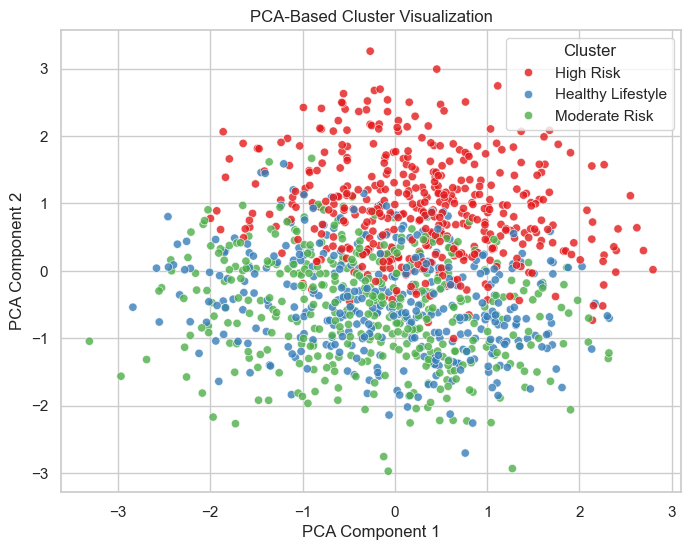

In [35]:
pca = PCA(n_components=2)
pca_values = pca.fit_transform(processed_df)

pca_df = pd.DataFrame(pca_values, columns=["PCA1", "PCA2"])
pca_df["cluster"] = df_clustered["cluster"].values
pca_df["cluster_name"] = df_clustered["cluster_name"].values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="cluster_name",
    palette="Set1",
    alpha=0.8
)
plt.title("PCA-Based Cluster Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

### 8.2 Cluster Size Distribution

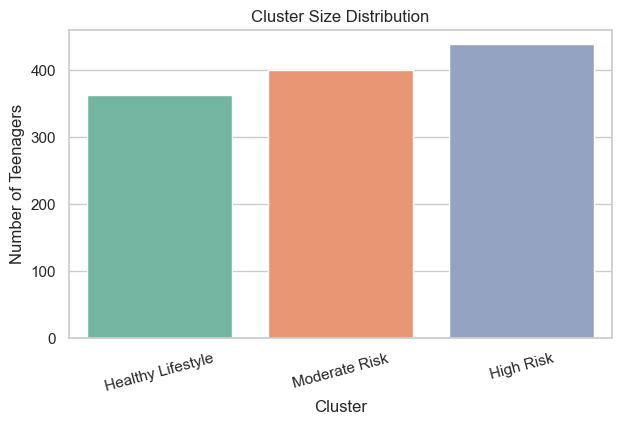

In [36]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df_clustered,
    x="cluster_name",
    order=["Healthy Lifestyle", "Moderate Risk", "High Risk"],
    palette="Set2"
)
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Teenagers")
plt.xticks(rotation=15)
plt.show()

### 8.3 Feature Comparison Across Clusters

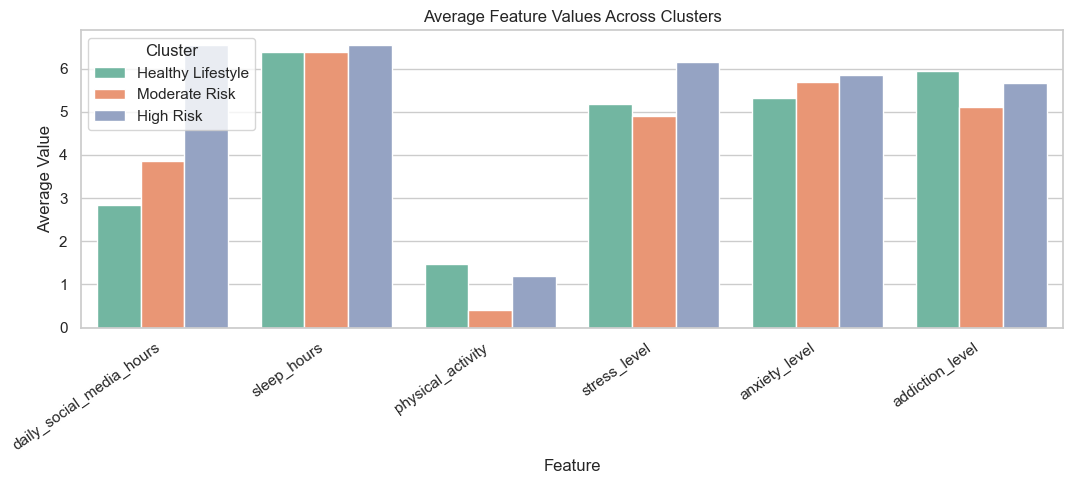

In [37]:
cluster_average = df_clustered.groupby(["cluster", "cluster_name"])[selected_features].mean().reset_index()
cluster_average_long = cluster_average.melt(
    id_vars=["cluster", "cluster_name"],
    value_vars=selected_features,
    var_name="feature",
    value_name="average_value"
)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=cluster_average_long,
    x="feature",
    y="average_value",
    hue="cluster_name",
    palette="Set2"
)
plt.title("Average Feature Values Across Clusters")
plt.xlabel("Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## 9. Insights and Findings

### Major EDA Findings

- The dataset contains teenagers aged 13 to 19.
- Social media usage, stress, anxiety, and addiction levels vary widely across teenagers.
- Depression label values are imbalanced, with far fewer teenagers labeled as 1.
- Students with depression label 1 show higher average social media usage, higher stress, higher anxiety, and lower sleep hours in this dataset.

### Cluster Characteristics

- **Healthy Lifestyle:** Lowest overall risk score after comparing lifestyle and mental health features.
- **Moderate Risk:** Middle group with moderate lifestyle and mental health risk patterns.
- **High Risk:** Highest overall risk score, with stronger warning signs in social media usage, stress, anxiety, and addiction indicators.

### Factors Associated with Higher Risk

- Higher daily social media hours
- Higher stress level
- Higher anxiety level
- Higher addiction level
- Lower sleep hours
- Lower physical activity

### Healthy vs High-Risk Groups

- Healthy students generally show better lifestyle balance.
- High-risk students show stronger negative patterns and should be monitored more carefully.

## 10. Recommendations

### For Students

- Build healthy social media habits by setting daily screen-time limits.
- Avoid using screens for long periods before sleeping.
- Follow a regular sleep routine.
- Add simple physical activity such as walking, sports, yoga, or stretching.
- Talk to a trusted adult, teacher, counselor, or parent when stress or anxiety feels high.

### For Parents

- Monitor screen time in a supportive way.
- Encourage offline hobbies and regular physical activity.
- Keep open communication about stress, anxiety, sleep, and online habits.
- Watch for sudden changes in sleep, mood, school performance, or social behavior.

### For Schools and Counselors

- Identify at-risk students early using simple surveys and counseling check-ins.
- Conduct mental health awareness sessions.
- Encourage sports, clubs, peer support, and balanced digital habits.
- Provide confidential counseling support for students with high stress or anxiety.

## 11. Conclusion

This project performed data loading, data cleaning, EDA, preprocessing, normalization, K-Means clustering, cluster interpretation, and visualization.

The K-Means model segmented teenagers into three groups:

- **Cluster 0:** Healthy Lifestyle
- **Cluster 1:** Moderate Risk
- **Cluster 2:** High Risk

The project shows how lifestyle factors such as social media usage, sleep, physical activity, stress, anxiety, and addiction level can be used to understand teen mental health risk groups. Regular monitoring and early support can help students build healthier routines and reduce risk.